In [1]:
import numpy as np 
from pathlib import Path 
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl

import matplotlib 
matplotlib.rcParams.update({'font.size': 10})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'

fig_out_dir = Path("final_figures/model_arch_figures")
fig_out_dir.mkdir(exist_ok=True, parents=True)

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Main 3d plot function

In [2]:
def plot_surface(ax, X, Y, Z, colors, shift_scale, num_channels, title, ylim=None, box_aspect=None, crop_outline_dim = None, title_xy=None, axs_fontsize=15, title_fontsize=18, plt_text=True):
    for i in range(num_channels):
        x_coord = X + (shift_scale*i)
        y_coord = Y + (shift_scale*i)
        z_coord = Z + (shift_scale*i)
        ax.plot_surface(x_coord, y_coord, z_coord, alpha=1, rstride=1, cstride=1, linewidth=0, edgecolor='k', facecolors=colors[:,:,i], antialiased=True, shade=False)
        if crop_outline_dim:
            x_coord = x_coord[:crop_outline_dim,:]
            y_coord = y_coord[:crop_outline_dim,:]
            z_coord = z_coord[:crop_outline_dim,:]
            
        ax.plot_surface(x_coord, y_coord, z_coord, rstride=1, cstride=1, alpha=0.0, linewidth=2, edgecolors='k', antialiased=True, shade=False)
    ax.view_init(elev=90, azim=0)
    if ylim is not None:
        ax.set_ylim(ylim)
    if box_aspect is not None:
        ax.set_box_aspect(box_aspect)
    ax.axis('off')
    time_str = "Time $\longrightarrow$"
    if 'Memory' in title or 'Gains' in title:
        time_str = "Time"
        title_y = -1 
    elif "Attended" in title:
        title_y = 2.75
    else:
        title_y = 3
    title_x = -2
    if title_xy is not None:
        title_x, title_y = title_xy
    if plt_text:
        ax.text(title_x, title_y, 0, title, color='black', fontsize=title_fontsize,)
        ax.text(-0.75, 0, 0, time_str, color='black', fontsize=axs_fontsize,)
        ax.text(7.5, -1, 0, "Channel", (45,45,0), color='black', fontsize=axs_fontsize)
        ax.text(3.66, -1.5, 0, "Frequency",  (90,0,0), color='black', fontsize=axs_fontsize)
    ax.margins(0)
    if box_aspect is None:
        scaling = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
        box_aspect = np.ptp(scaling, axis=1)
        ax.set_box_aspect(box_aspect)
        return box_aspect
    

# Main pieces - plot together to preserve size and aspect 

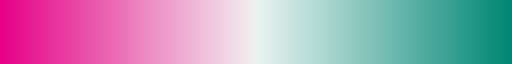

In [3]:
sns.diverging_palette(348, 172, s=100, as_cmap=True)

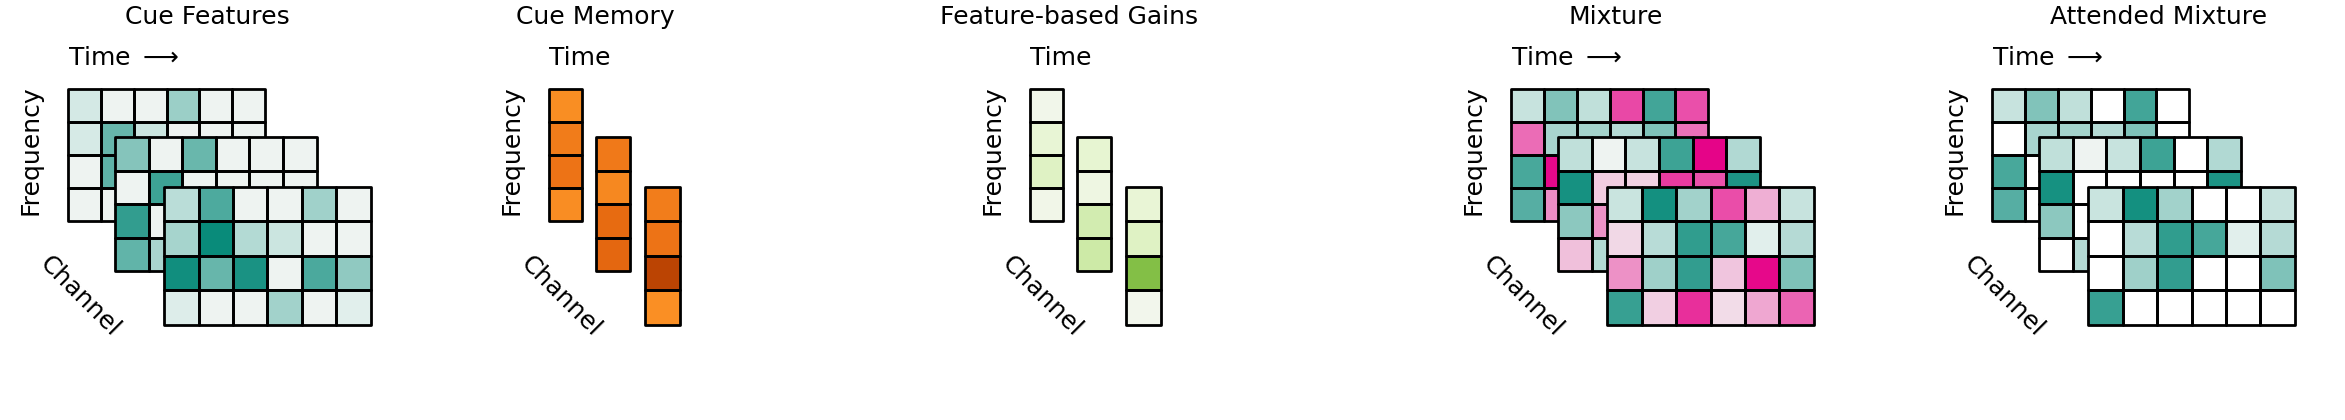

In [4]:


np.random.seed(0)
figsize=(30, 6)
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(151, projection='3d')

num_channels = 3
seq_len = 7
freq_size = 5

x = np.arange(0, freq_size)
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)
max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)
feature_map[feature_map < pixel_tol] = 0.5
colors = sns.diverging_palette(348, 172, s=100, as_cmap=True)(feature_map) # plt.cm.RdBu(feature_map)
shift_scale = 1.5

box_aspect = plot_surface(ax, X, Y, Z, colors, shift_scale, num_channels, "Cue Features", axs_fontsize=18, title_xy=(-2, 1.75))

ax2 = fig.add_subplot(152, projection='3d')
y = np.arange(0, 2)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map_avg = np.mean(feature_map, axis=0, keepdims=True)
colors = plt.cm.YlOrBr(feature_map_avg)

plot_surface(ax2, X, Y, Z, colors, shift_scale, num_channels, "Cue Memory", ylim=ax.get_ylim(), box_aspect=box_aspect, axs_fontsize=18)

ax3 = fig.add_subplot(153, projection='3d')
colors = plt.cm.PiYG(feature_map_avg)

plot_surface(ax3, X, Y, Z, colors, shift_scale, num_channels, "Feature-based Gains", ylim=ax.get_ylim(), box_aspect=box_aspect, axs_fontsize=18, title_xy=(-2, -2.75))

ax4 = fig.add_subplot(154, projection='3d')
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)
colors = sns.diverging_palette(348, 172, s=100, as_cmap=True)(feature_map) # plt.cm.RdBu(feature_map)

plot_surface(ax4, X, Y, Z, colors, shift_scale, num_channels, "Mixture", box_aspect=box_aspect, axs_fontsize=18, title_xy=(-2, 1.75))

ax5 = fig.add_subplot(155, projection='3d')
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

# feature_map = np.random.rand(seq_len, freq_size, num_channels)
# colors = plt.cm.RdBu(feature_map)
colors[feature_map < pixel_tol] = 1

plot_surface(ax5, X, Y, Z, colors, shift_scale, num_channels, "Attended Mixture", box_aspect=box_aspect, axs_fontsize=18, title_xy=(-2, 1.75))

# save figure as pdf with no backing 
out_dir = Path("model_arch_figs")
out_dir.mkdir(exist_ok=True, parents=True)
# plt.savefig(fig_out_dir / "fake_activation_pieces_4x6x3_teal_pink.pdf", bbox_inches='tight', transparent=True)  


In [5]:
feature_map[:,:,1]

array([[0.59204193, 0.95274901, 0.69947928, 0.39650574, 0.88173536],
       [0.50132438, 0.42385505, 0.30157482, 0.61801543, 0.29828233],
       [0.57432525, 0.43141844, 0.43586493, 0.70388858, 0.7142413 ],
       [0.86812606, 0.12381998, 0.56910074, 0.69742877, 0.86638233],
       [0.01171408, 0.17162968, 0.19999652, 0.22392469, 0.7044144 ],
       [0.6214784 , 0.934214  , 0.58990998, 0.39822106, 0.94437239],
       [0.22741463, 0.43441663, 0.37775184, 0.06724963, 0.53657921]])

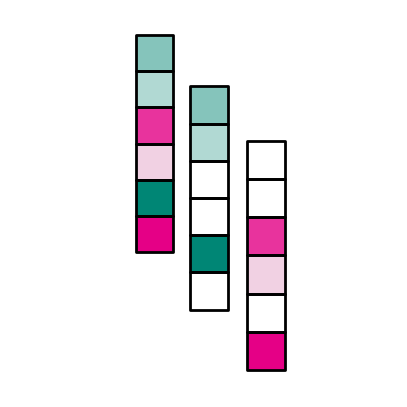

In [6]:


np.random.seed(10)
figsize=(5, 6)
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

num_channels = 3
seq_len = 1
freq_size = 7

x = np.arange(0, freq_size)
y = np.arange(0, 2)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.randn(seq_len, freq_size, num_channels)
max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)

feature_map[...,0] = feature_map[:,:,1]
feature_map[...,2] = feature_map[:,:,1]



# max_val = np.max(feature_map)
# pixel_tol = max_val - (max_val * 0.5)
# feature_map[feature_map < pixel_tol] = 0.5
colors = sns.diverging_palette(348, 172, s=100, as_cmap=True)(feature_map) # plt.cm.RdBu(feature_map)

colors_tgt = colors[:,:,1]
colors_tgt[feature_map[:,:,1] < 0.5] = 1 

colors_dist = colors[:,:,2]
colors_dist[feature_map[:,:,2] > 0.5] = 1 


shift_scale = 1.5

box_aspect = plot_surface(ax, X, Y, Z, colors, shift_scale, num_channels, "For selection", axs_fontsize=18, title_xy=(-2, 1.75), plt_text=False)


# save figure as pdf with no backing 
# plt.savefig(fig_out_dir / "mix_tgt_distract_for_corr_fig.pdf", bbox_inches='tight', transparent=True)  


# Plot time average text 

(0.0, 1.0, 0.0, 1.0)

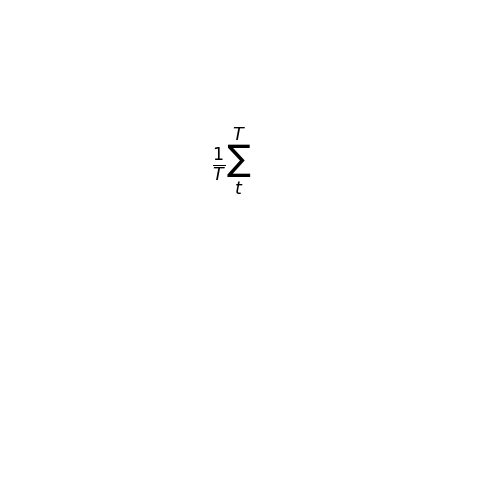

In [7]:
fig = plt.figure(figsize=(6, 6))
ax2 = fig.add_subplot(111,)

## Add text 
shared_y = 0.65
ax2.text(0.435, shared_y, "$\\frac{1}{T}\sum_{t}^{T}$", color='black', fontsize=18, horizontalalignment='left')
# align title over the middle of the plot
# change color of characters 'memory' to be orange
ax2.axis('off')
# plt.tight_layout()
# plt.savefig(fig_out_dir / "frac_sum_txt.pdf", bbox_inches='tight', pad_inches=0, transparent=True)


(0.0, 1.0, 0.0, 1.0)

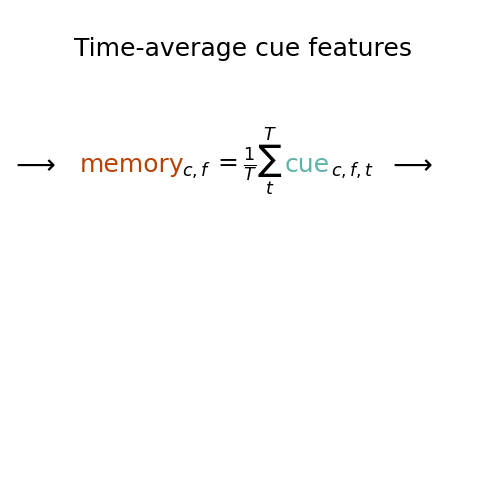

In [21]:
fig = plt.figure(figsize=(6, 6))
ax2 = fig.add_subplot(111,)
tgt_mix_palette = sns.diverging_palette(348, 172, s=100, as_cmap=True)
## Add text 
shared_y = 0.65
ax2.text(0, shared_y, "$\longrightarrow$", color='black', fontsize=20, horizontalalignment='left')
ax2.text(0.15, shared_y, "memory", color= plt.cm.YlOrBr(0.8), fontsize=18, horizontalalignment='left')
ax2.text(0.37, shared_y,  "$_{c,f}$", color='black', fontsize=18, horizontalalignment='left')
ax2.text(0.436, shared_y, "$=\\frac{1}{T}\sum_{t}^{T}$", color='black', fontsize=18, horizontalalignment='left')
ax2.text(0.59, shared_y, "cue", color=tgt_mix_palette(0.8), fontsize=18, horizontalalignment='left')
ax2.text(0.69,shared_y,  "$_{c,f,t}$", color='black', fontsize=18, horizontalalignment='left')
ax2.text(0.81, shared_y, "$\longrightarrow$", color='black', fontsize=20, horizontalalignment='left')
# align title over the middle of the plot
ax2.text(0.5, 0.9, "Time-average cue features", color='black', fontsize=18, horizontalalignment='center')
# change color of characters 'memory' to be orange
ax2.axis('off')
# plt.tight_layout()
# plt.savefig(fig_out_dir / "time_avg_text.pdf", bbox_inches='tight', pad_inches=0, transparent=True)


Text(0.5, 1.2, 'Gain function')

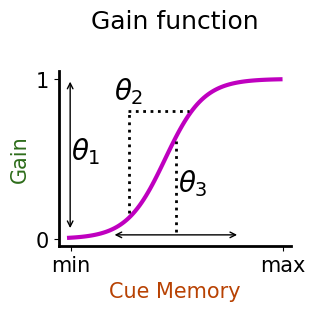

In [22]:
fig = plt.figure(figsize=(6, 6))
ax2 = fig.add_subplot(111,)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

sig_x = np.linspace(-5, 6,100)
ax2.plot(sigmoid(sig_x), 'm', linewidth=3)
# add dashed line at x = 50 

ax2.axvline(x=50, ymin=0.08, ymax=0.6, color='k', linestyle=':', linewidth=2)
ax2.axvline(x=28, ymin=0.19, ymax=0.78, color='k', linestyle=':', linewidth=2)
ax2.axhline(y=0.8, xmin=0.3, xmax=0.56, color='k', linestyle=':', linewidth=2)
ax2.text(7.75, 0.5, "$\\theta_1$", color='black', fontsize=20, horizontalalignment='center')
ax2.text(28, 0.875, "$\\theta_2$", color='black', fontsize=20, horizontalalignment='center')
ax2.text(58, 0.3, "$\\theta_3$", color='black', fontsize=20, horizontalalignment='center')
# add vertical bidirectional arrow 
ax2.annotate("", xy=(0.5, 0.05), xytext=(0.5, 1),
             arrowprops=dict(arrowstyle="<->", lw=1))
ax2.annotate("", xy=(20, 0.025), xytext=(80, 0.025),
             arrowprops=dict(arrowstyle="<->", lw=1))

ax2.set_xticks([1,100])
ax2.set_xticklabels(['min', 'max'], fontsize=15);
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["0", "1"] , fontsize=15)
ax2.set_xlabel('Cue Memory', fontsize=15, color=plt.cm.YlOrBr(0.8))
ax2.set_ylabel('Gain', fontsize=15,  color=plt.cm.PiYG(0.98))
# ax2.text(-40, 0.5, "$\longrightarrow$", color='black', fontsize=20, horizontalalignment='center')
# ax2.text(110, 0.5, "$\longrightarrow$", color='black', fontsize=20, horizontalalignment='center')

# remove top and right spines
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(2)
ax2.spines['bottom'].set_linewidth(2)
# set aspect ratio to match ax
ax2.set_box_aspect(0.75)

# make 25% smaller
pos = ax2.get_position()
scale = 0.5
pos.x0 *= scale
pos.y0 *= scale
pos.x1 *= scale
pos.y1 *= scale
ax2.set_position(pos)

# ax2.text(50, 1.19, "Gain function", color='black', fontsize=18, horizontalalignment='center',)
ax2.set_title("Gain function", color='black', fontsize=18, horizontalalignment='center', y = 1.2)
# plt.tight_layout()
# plt.savefig(fig_out_dir / "gain_fn.pdf", bbox_inches='tight', pad_inches=0, transparent=True)


## Obtaining memory

(10, 5, 3, 4)


Text(0.45, 0.9, 'Store memory of cue features')

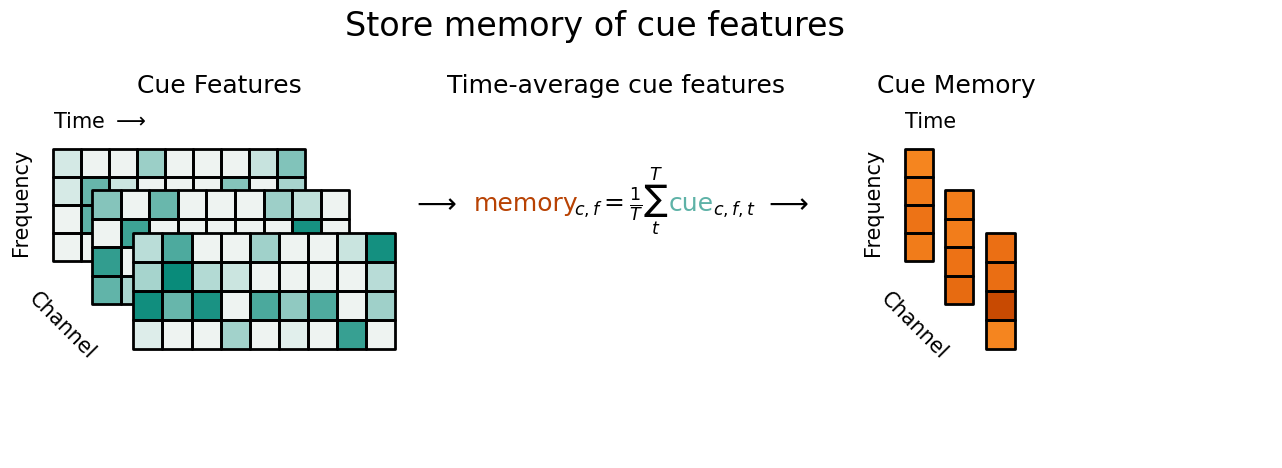

In [29]:


np.random.seed(0)
figsize=(18, 6)
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(131, projection='3d')

num_channels = 3
seq_len = 10
freq_size = 5

x = np.arange(0, freq_size)
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)
max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)
feature_map[feature_map < pixel_tol] = 0.5
colors = tgt_mix_palette(feature_map)
print(colors.shape)
shift_scale = 1.5

box_aspect = plot_surface(ax, X, Y, Z, colors, shift_scale, num_channels, "Cue Features")

ax2 = fig.add_subplot(132, projection='3d')
ax2.view_init(elev=90, azim=0)

## Add text 
ax2.text(-.135, 0.1, 0, "Time-average cue features", color='black', fontsize=18, horizontalalignment='center')
shared_x = 0.35
ax2.text(shared_x, -0.65, 0, "$\longrightarrow$", color='black', fontsize=20, horizontalalignment='center')
ax2.text(shared_x, -0.27, 0, "memory", color= plt.cm.YlOrBr(0.8), fontsize=18, horizontalalignment='center')
ax2.text(shared_x, -0.01, 0, "$_{c,f}$", color='black', fontsize=18, horizontalalignment='center')
# ax2.text(shared_x, 0.175, 0, "$=\sum_{t}^{T}$", color='black', fontsize=18, horizontalalignment='center')
ax2.text(shared_x,  0.175, 0, "$=\\frac{1}{T}\sum_{t}^{T}$", color='black', fontsize=18, horizontalalignment='center')
ax2.text(shared_x, 0.41, 0, "cue", color=tgt_mix_palette(0.8), fontsize=18, horizontalalignment='center')
ax2.text(shared_x, 0.59, 0, "$_{c,f,t}$", color='black', fontsize=18, horizontalalignment='center')
ax2.text(shared_x, 0.8, 0, "$\longrightarrow$", color='black', fontsize=20, horizontalalignment='center')

# change color of characters 'memory' to be orange
ax2.axis('off')

ax3 = fig.add_subplot(133, projection='3d')
y = np.arange(0, 2)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map_avg = np.mean(feature_map, axis=0, keepdims=True)
colors = plt.cm.YlOrBr(feature_map_avg)

plot_surface(ax3, X, Y, Z, colors, shift_scale, num_channels, "Cue Memory", ylim=ax.get_ylim(), box_aspect=box_aspect)

# move ax3 to left 
# get current position
pos = ax3.get_position()
# set new position
pos.x0 = 0.525

ax3.set_position(pos)
# 
# colors = plt.cm.PiYG(feature_map_avg)

# plot_surface(ax3, X, Y, Z, colors, shift_scale, num_channels, "Feature-based Gains", ylim=ax.get_ylim(), box_aspect=box_aspect)

# ax4 = fig.add_subplot(144, projection='3d')
# y = np.arange(0, seq_len)
# X, Y = np.meshgrid(x, y)
# Z = np.zeros_like(X)

# feature_map = np.random.rand(seq_len, freq_size, num_channels)
# colors = plt.cm.RdBu(feature_map)
fig.suptitle("Store memory of cue features", fontsize=24, y=.9, x=0.45)
# plt.savefig(fig_out_dir / "obtain_memory.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

# plot_surface(ax4, X, Y, Z, colors, shift_scale, num_channels, "Mixture", box_aspect=box_aspect)

## Obtaining gains

Text(0.36, 0.9, 'Gains are function of cue memory')

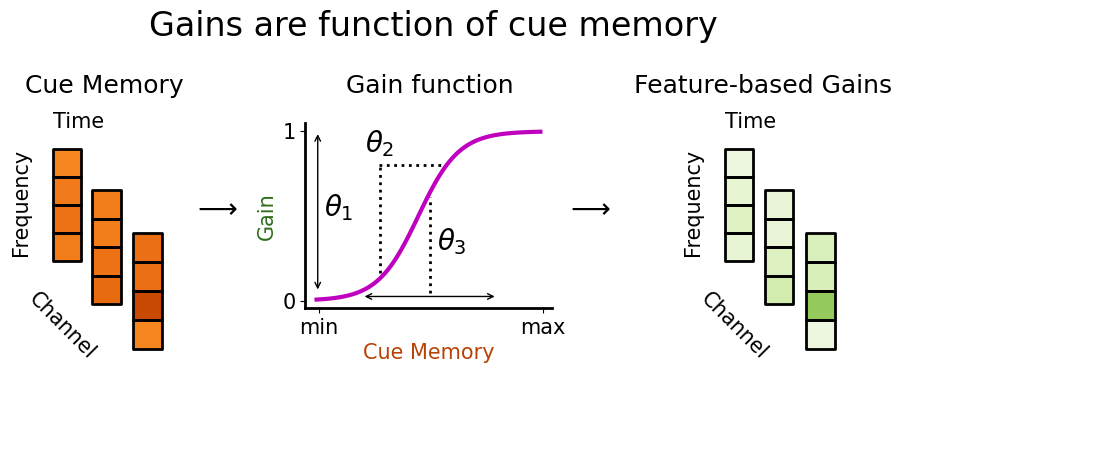

In [30]:


np.random.seed(0)
figsize=(18, 6)
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(131, projection='3d')

num_channels = 3
seq_len = 10
freq_size = 5

x = np.arange(0, freq_size)
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)
max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)
feature_map[feature_map < pixel_tol] = 0.5

feature_map_avg = np.mean(feature_map, axis=0, keepdims=True)

colors = plt.cm.YlOrBr(feature_map_avg)

colors = np.concatenate([colors, np.ones((9, freq_size, 3, 4))], axis=0)
# print(colors.shape)
# append 9 empty channels to first dim of colors 
shift_scale = 1.5

box_aspect = plot_surface(ax, X, Y, Z, colors, shift_scale, num_channels, "Cue Memory", crop_outline_dim=2)

ax2 = fig.add_subplot(132, )

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

sig_x = np.linspace(-5, 6,100)
ax2.plot(sigmoid(sig_x), 'm', linewidth=3)
# add dashed line at x = 50 

ax2.axvline(x=50, ymin=0.08, ymax=0.6, color='k', linestyle=':', linewidth=2)
ax2.axvline(x=28, ymin=0.19, ymax=0.78, color='k', linestyle=':', linewidth=2)
ax2.axhline(y=0.8, xmin=0.3, xmax=0.56, color='k', linestyle=':', linewidth=2)
ax2.text(10, 0.5, "$\\theta_1$", color='black', fontsize=20, horizontalalignment='center')
ax2.text(28, 0.875, "$\\theta_2$", color='black', fontsize=20, horizontalalignment='center')
ax2.text(60, 0.3, "$\\theta_3$", color='black', fontsize=20, horizontalalignment='center')
# add vertical bidirectional arrow 
ax2.annotate("", xy=(0.5, 0.05), xytext=(0.5, 1),
             arrowprops=dict(arrowstyle="<->", lw=1))
ax2.annotate("", xy=(20, 0.025), xytext=(80, 0.025),
             arrowprops=dict(arrowstyle="<->", lw=1))

ax2.set_xticks([1,100])
ax2.set_xticklabels(['min', 'max'], fontsize=15);
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["0", "1"] , fontsize=15)
ax2.set_xlabel('Cue Memory', fontsize=15, color=plt.cm.YlOrBr(0.8))
ax2.set_ylabel('Gain', fontsize=15,  color=plt.cm.PiYG(0.98))
ax2.text(50, 1.225, "Gain function", color='black', fontsize=18, horizontalalignment='center')
ax2.text(-45, 0.5, "$\longrightarrow$", color='black', fontsize=20, horizontalalignment='center')
ax2.text(120, 0.5, "$\longrightarrow$", color='black', fontsize=20, horizontalalignment='center')

# remove top and right spines
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(2)
ax2.spines['bottom'].set_linewidth(2)
# set aspect ratio to match ax
ax2.set_box_aspect(0.75)

# make 25% smaller
pos = ax2.get_position()
scale_factor = 0.6
pos.x0 *= scale_factor 
pos.y0 *= scale_factor
pos.x1 *= scale_factor
pos.y1 *= scale_factor

y_shift = 0.26
x_shift = .05
pos.y1 = pos.y1 + y_shift
pos.y0 = pos.y0 + y_shift
pos.x0 = pos.x0 + x_shift
pos.x1 = pos.x1 + x_shift
# pos.y0 = 0
# pos.y1 = 1.2
# pos.x1 = 0.4
ax2.set_position(pos)



ax3 = fig.add_subplot(133, projection='3d')
y = np.arange(0, 2)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)


colors = plt.cm.PiYG(feature_map_avg)
plot_surface(ax3, X, Y, Z, colors, shift_scale, num_channels, "Feature-based Gains", ylim=ax.get_ylim(), box_aspect=box_aspect, title_xy=(-2,  -3.25))

# move ax3 to left 
# get current position
pos = ax3.get_position()
# set new position
pos.x0 = 0.325

ax3.set_position(pos)
# 
# change position of text in ax3 that starts with "Feature"

# colors = plt.cm.PiYG(feature_map_avg)

# plot_surface(ax3, X, Y, Z, colors, shift_scale, num_channels, "Feature-based Gains", ylim=ax.get_ylim(), box_aspect=box_aspect)

# ax4 = fig.add_subplot(144, projection='3d')
# y = np.arange(0, seq_len)
# X, Y = np.meshgrid(x, y)
# Z = np.zeros_like(X)

# feature_map = np.random.rand(seq_len, freq_size, num_channels)
# colors = plt.cm.RdBu(feature_map)
fig.suptitle("Gains are function of cue memory", fontsize=24, y=.9, x=0.36)
# plt.savefig(fig_out_dir / "gains_fn_mem.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

# plot_surface(ax4, X, Y, Z, colors, shift_scale, num_channels, "Mixture", box_aspect=box_aspect)

## Applying Gains 

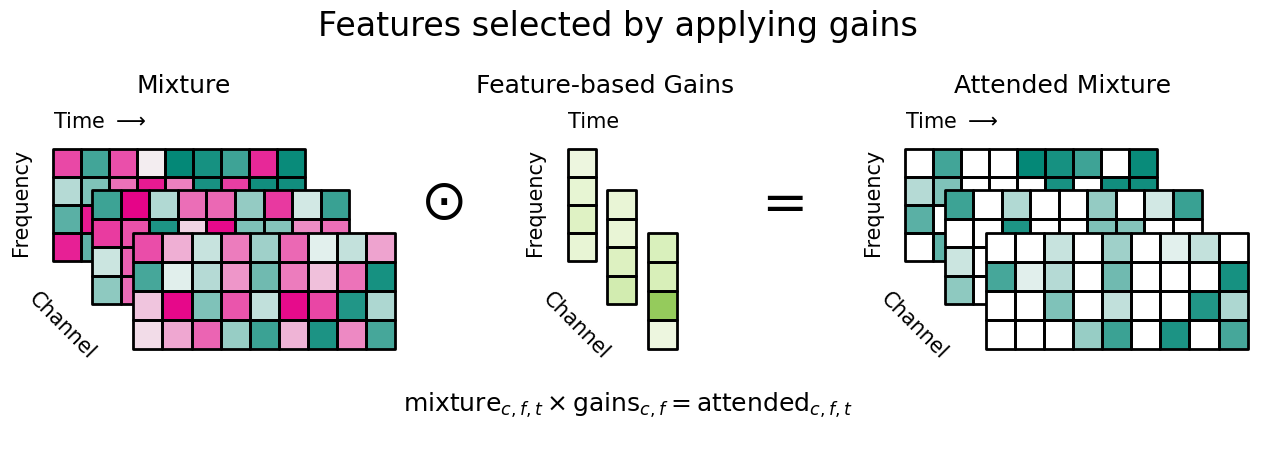

In [38]:
fig = plt.figure(figsize=(18, 6))
np.random.seed(0)

## init array 
num_channels = 3
seq_len = 10
freq_size = 5

x = np.arange(0, freq_size)
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)
max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)
feature_map[feature_map < pixel_tol] = 0.5
colors = tgt_mix_palette(feature_map)
shift_scale = 1.5

ax1 = fig.add_subplot(131, projection='3d')
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map_mix = np.random.rand(seq_len, freq_size, num_channels)
colors = tgt_mix_palette(feature_map_mix)

plot_surface(ax1, X, Y, Z, colors, shift_scale, num_channels, "Mixture", box_aspect=box_aspect)
pos = ax1.get_position()
pos.x0 = 0.1
# pos.x1 += 0.4
ax1.set_position(pos)

ax2 = fig.add_subplot(132, projection='3d')

y = np.arange(0, 2)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map_avg = np.mean(feature_map, axis=0, keepdims=True)
colors_gain = plt.cm.PiYG(feature_map_avg)

plot_surface(ax2, X, Y, Z, colors_gain, shift_scale, num_channels, "Feature-based Gains", ylim=ax.get_ylim(), box_aspect=box_aspect, title_xy=(-2, -3.25))
ax2.text(2.5, -5.25, 0, "$\odot$", color='black', fontsize=40,)
# pos = ax2.get_position()
# pos.x0 = 0.4
# # pos.x1 += 0.4
# ax2.set_position(pos)

ax3 = fig.add_subplot(133, projection='3d')
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

# feature_map = np.random.rand(seq_len, freq_size, num_channels)
# colors = plt.cm.RdBu(feature_map)
colors[feature_map_mix < pixel_tol] = 1

plot_surface(ax3, X, Y, Z, colors, shift_scale, num_channels, "Attended Mixture", box_aspect=box_aspect, title_xy=(-2, 1.75))
ax3.text(2.5, -5.5, 0, "$=$", color='black', fontsize=40,)
pos = ax3.get_position()
pos.x0 = 0.5
# pos.x1 += 0.4
ax3.set_position(pos)

fig.suptitle("Features selected by applying gains", fontsize=24, y=.9, x=0.45)
# fig.suptitle("Features selected by dfsa gains", fontsize=24, y=.9, x=0.45)
ax2.set_title('mixture$_{c,f,t} \\times $gains$_{c,f} = $attended$_{c,f,t}$', fontsize=18, y=0.1, x=0.25)
# save figure as pdf with no backing 
out_dir = Path("model_arch_figs")
out_dir.mkdir(exist_ok=True, parents=True)

# plt.savefig(fig_out_dir / "mix_gain_attn.pdf", bbox_inches='tight', pad_inches=0, transparent=True)


# Normalization 

In [52]:
def softmax(x):
    return np.exp(x)/sum(np.exp(x))
     

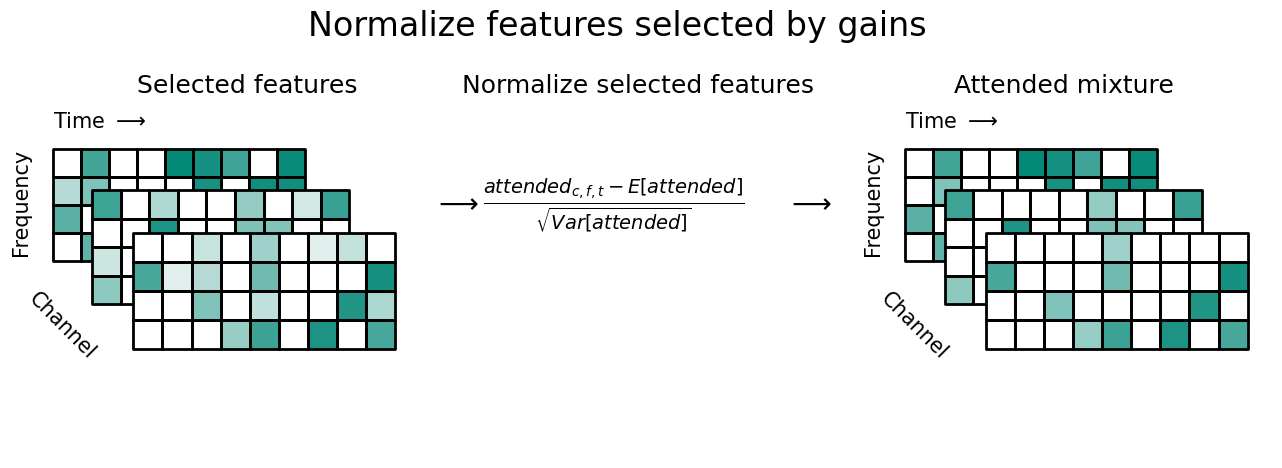

In [ ]:
fig = plt.figure(figsize=(18, 6))
np.random.seed(0)

## init array 
num_channels = 3
seq_len = 10
freq_size = 5

x = np.arange(0, freq_size)
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)


feature_map = np.random.rand(seq_len, freq_size, num_channels)
max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)
feature_map[feature_map < pixel_tol] = 0.5
colors = tgt_mix_palette(feature_map)
shift_scale = 1.5

#### Plot attended mixture
ax1 = fig.add_subplot(131, projection='3d')
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map_mix = np.random.rand(seq_len, freq_size, num_channels)
colors = tgt_mix_palette(feature_map_mix)
colors[feature_map_mix < pixel_tol] = 1

plot_surface(ax1, X, Y, Z, colors, shift_scale, num_channels, "Selected features", box_aspect=box_aspect)
pos = ax1.get_position()
pos.x0 = 0.1
# pos.x1 += 0.4
ax1.set_position(pos)

#### Plot equation for normalization
ax2 = fig.add_subplot(132, projection='3d')
ax2.view_init(elev=90, azim=0)

## Add text 
ax2.text(-.135, 0.1, 0, "Normalize selected features", color='black', fontsize=18, horizontalalignment='center')
shared_x = 0.35
ax2.text(shared_x, -0.65, 0, "$\longrightarrow$", color='black', fontsize=20, horizontalalignment='center')
ax2.text(shared_x,  0.0, 0, "$\\frac{attended_{c,f,t} - E[attended]}{\sqrt{Var[attended]}}$", color='black', fontsize=20, horizontalalignment='center')
ax2.text(shared_x, 0.8, 0, "$\longrightarrow$", color='black', fontsize=20, horizontalalignment='center')
ax2.axis('off')

#### Plot normalized attended mixture
ax3 = fig.add_subplot(133, projection='3d')
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

attended = feature_map_mix.copy()
# attended[attended < pixel_tol] = 0
attended = (attended - attended.mean()) / attended.std()
# feature_mean = colors.ravel().mean()
# feature_std = colors.ravel().std()

# normed_colors[normed_colors < pixel_tol ] = 1
# normed_colors = softmax(normed_colors)
# normed_colors += np.abs(np.min(normed_colors))
# normed_colors = np.clip(normed_colors, 0, 1)
# normed_colors /= np.max(normed_colors)
# project back to 0 to 1 range 
# normed_colors = (normed_colors - np.min(normed_colors)) / (np.max(normed_colors) - np.min(normed_colors))
attended_colors = colors.copy()
attended_colors[attended < pixel_tol] = 1

plot_surface(ax3, X, Y, Z, attended_colors, shift_scale, num_channels, "Attended mixture", box_aspect=box_aspect, title_xy=(-2, 1.75))
pos = ax3.get_position()
pos.x0 = 0.5
# pos.x1 += 0.4
ax3.set_position(pos)


fig.suptitle("Normalize features selected by gains", fontsize=24, y=.9, x=0.45)
# save figure as pdf with no backing 
out_dir = Path("model_arch_figs")
out_dir.mkdir(exist_ok=True, parents=True)

# plt.savefig(fig_out_dir / "normalize_selected_features.pdf", bbox_inches='tight', pad_inches=0, transparent=True)


In [110]:
(attended - attended.mean()) / attended.std()

array([[[-0.95177155,  1.24294777, -0.95177155],
        [ 0.60443156, -0.95177155,  1.19208766],
        [ 1.08922065,  0.48697847, -0.95177155],
        [-0.95177155,  0.81140603, -0.95177155],
        [ 0.87366539,  1.23853942,  1.51445542]],

       [[ 1.21179457, -0.95177155, -0.95177155],
        [ 0.89372586, -0.95177155,  0.365467  ],
        [-0.95177155, -0.95177155, -0.95177155],
        [ 1.0547846 , -0.95177155, -0.95177155],
        [ 1.39452128,  0.82906648, -0.95177155]],

       [[-0.95177155,  0.61939504,  0.50752658],
        [-0.95177155,  1.41002544,  0.60040274],
        [ 0.40236781,  0.53958654,  0.89405822],
        [-0.95177155, -0.95177155, -0.95177155],
        [-0.95177155,  1.43570699,  0.91789519]],

       [[-0.95177155, -0.95177155, -0.95177155],
        [-0.95177155, -0.95177155, -0.95177155],
        [ 0.80866231, -0.95177155, -0.95177155],
        [-0.95177155, -0.95177155,  0.76580902],
        [-0.95177155,  0.40476043,  1.3151133 ]],

       [[ 1.

In [75]:
colors


array([[[[1.        , 1.        , 1.        , 1.        ],
         [0.23731332, 0.63725773, 0.58482907, 1.        ],
         [1.        , 1.        , 1.        , 1.        ]],

        [[0.70831194, 0.8567874 , 0.83399833, 1.        ],
         [1.        , 1.        , 1.        , 1.        ],
         [0.27326849, 0.65401622, 0.60385019, 1.        ]],

        [[0.35236985, 0.69088489, 0.64569666, 1.        ],
         [0.79460434, 0.89700777, 0.87964902, 1.        ],
         [1.        , 1.        , 1.        , 1.        ]],

        [[1.        , 1.        , 1.        , 1.        ],
         [0.55730025, 0.78640174, 0.75410962, 1.        ],
         [1.        , 1.        , 1.        , 1.        ]],

        [[0.51415405, 0.76629155, 0.73128428, 1.        ],
         [0.24450435, 0.64060943, 0.58863329, 1.        ],
         [0.04315543, 0.54676188, 0.48211501, 1.        ]]],


       [[[0.25888642, 0.64731282, 0.59624174, 1.        ],
         [1.        , 1.        , 1.        

# Old demos

Text(3.66, -1.5, 'Frequency')

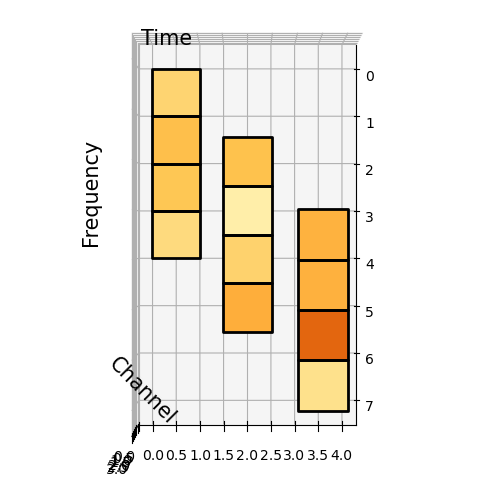

In [252]:
np.random.seed(0)
# Create a 3D plot to represent a batch of samples
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# Parameters
num_channels = 3
seq_len = 10
freq_size = 5

# Generate coordinates for the 3D plot

x = np.arange(0, freq_size)
y = np.arange(0, 2)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)
max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)
feature_map[feature_map < pixel_tol] = 0

feature_map = np.mean(feature_map, axis=0, keepdims=True)
colors = plt.cm.YlOrBr(feature_map)
# colors = plt.cm.bwr_r(feature_map)



shift_scale = 1.5 # make sure is not even or pannels will appear to overlap
# Plot each sample in the batch
for i in range(num_channels):
    # plot with actual colors  
    x_coord = X + (shift_scale*i)
    y_coord = Y + (shift_scale*i)
    z_coord = Z + (shift_scale*i)
    ax.plot_surface(x_coord, y_coord, z_coord, alpha=1, rstride=1, cstride=1, linewidth=0, edgecolor='k', facecolors=colors[:,:,i], antialiased=True, shade=False)
    # Plot the surface again to add edgecolors
    ax.plot_surface(x_coord, y_coord, z_coord, rstride=1, cstride=1, alpha=0.0, linewidth=2, edgecolors='k', antialiased=True, shade=False)

# Customize ticks
# ax.set_xticks(np.arange(0, seq_len, step=1))
# ax.set_yticks(np.arange(0, freq_size, step=1))
# ax.set_zticks(np.arange(0, num_channels, step=1))
ax.view_init(elev=90, azim=0)

# Set aspect ratio
scaling = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
# ax.auto_scale_xyz(*[[np.min(scaling), np.max(scaling)]]*3)
box_aspect = np.ptp(scaling, axis=1)
ax.set_box_aspect(box_aspect)
# plt.axis('off')
# Add axis labels as text 
ax.text(-0.5, -0.25, 0, "Time", color='black', fontsize=15,)
ax.text(7.5, -1, 0, "Channel", (45,45,0), color='black', fontsize=15)
ax.text(3.66, -1.5, 0, "Frequency",  (90,0,0), color='black', fontsize=15)
# ax.set_box_aspect(box_aspect)

# ax.set_xlabel('Frequency')


# Title
# plt.title('Batch of 5 Samples.\n(Samples x Seq Len x Embedding size)')

# plt.show()


NameError: name 'scaling' is not defined

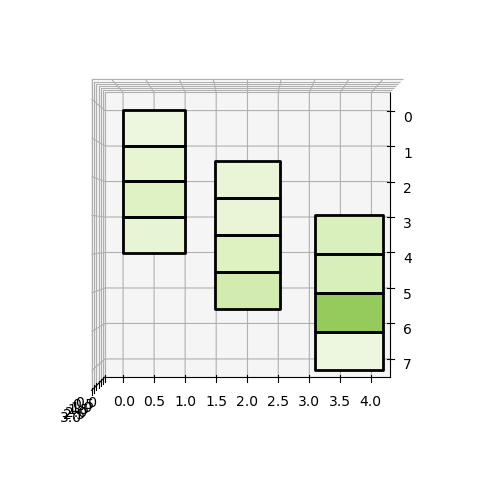

In [304]:

np.random.seed(0)
# Create a 3D plot to represent a batch of samples
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# Parameters
num_channels = 3
seq_len = 10
freq_size = 5

# Generate coordinates for the 3D plot

x = np.arange(0, freq_size)
y = np.arange(0, 2)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)
max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)
feature_map[feature_map < pixel_tol] = 0.5

feature_map = np.mean(feature_map, axis=0, keepdims=True)
colors = plt.cm.PiYG(feature_map)
# colors = plt.cm.bwr_r(feature_map)



shift_scale = 1.5 # make sure is not even or pannels will appear to overlap
# Plot each sample in the batch
for i in range(num_channels):
    # plot with actual colors  
    x_coord = X + (shift_scale*i)
    y_coord = Y + (shift_scale*i)
    z_coord = Z + (shift_scale*i)
    ax.plot_surface(x_coord, y_coord, z_coord, alpha=1, rstride=1, cstride=1, linewidth=0, edgecolor='k', facecolors=colors[:,:,i], antialiased=True, shade=False)
    # Plot the surface again to add edgecolors
    ax.plot_surface(x_coord, y_coord, z_coord, rstride=1, cstride=1, alpha=0.0, linewidth=2, edgecolors='k', antialiased=True, shade=False)

# Customize ticks
# ax.set_xticks(np.arange(0, seq_len, step=1))
# ax.set_yticks(np.arange(0, freq_size, step=1))
# ax.set_zticks(np.arange(0, num_channels, step=1))
ax.view_init(elev=90, azim=0)

# Set aspect ratio
# scaling = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
ax.auto_scale_xyz(*[[np.min(scaling), np.max(scaling)]]*3)

plt.axis('off')
# Add axis labels as text 
ax.text(-0.5, -0.25, 0, "Time", color='black', fontsize=15,)
ax.text(7.5, -1, 0, "Channel", (45,45,0), color='black', fontsize=15)
ax.text(3.66, -1.5, 0, "Frequency",  (90,0,0), color='black', fontsize=15)
ax.set_box_aspect(box_aspect)
ax.margins(x=0,y=0,z=0)

# ax.set_xlabel('Frequency')


# Title
# plt.title('Batch of 5 Samples.\n(Samples x Seq Len x Embedding size)')

# plt.show()


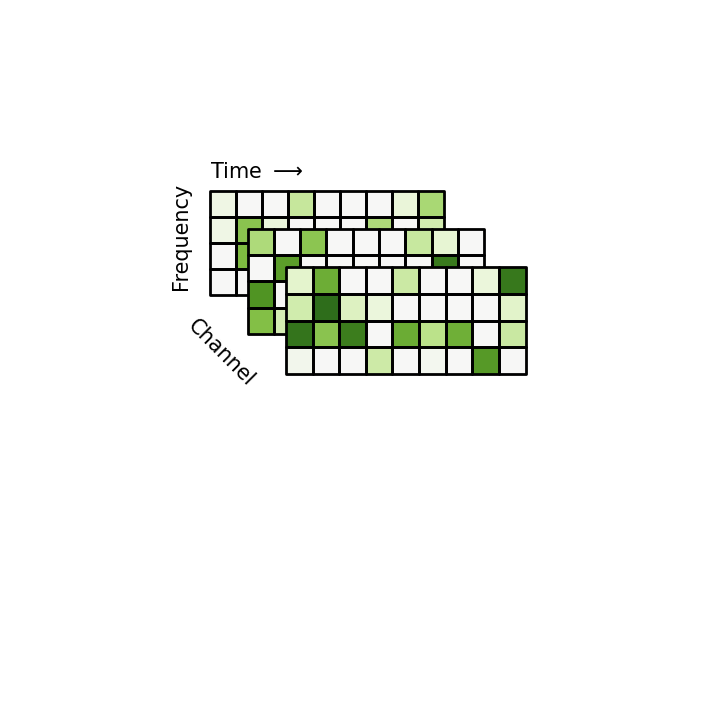

In [174]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
# Create a 3D plot to represent a batch of samples
box_aspect = (1, 1, 1) 
figsize=(9, 9)
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# Parameters
num_channels = 3
seq_len = 10
freq_size = 5

# Generate coordinates for the 3D plot
x = np.arange(0, freq_size)
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)

max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)
feature_map[feature_map < pixel_tol] = 0.5

colors = plt.cm.PiYG(feature_map)
# colors = plt.cm.bwr_r(feature_map)

# max_val = np.max(feature_map)
# pixel_tol = max_val - (max_val * 0.5)

# colors[feature_map < pixel_tol] = 1

shift_scale = 1.5 # make sure is not even or pannels will appear to overlap
# Plot each sample in the batch
for i in range(num_channels):
    # plot with actual colors  
    x_coord = X + (shift_scale*i)
    y_coord = Y + (shift_scale*i)
    z_coord = Z + (shift_scale*i)
    ax.plot_surface(x_coord, y_coord, z_coord, alpha=1, rstride=1, cstride=1, linewidth=0, edgecolor='k', facecolors=colors[:,:,i], antialiased=True, shade=False)
    # Plot the surface again to add edgecolors
    ax.plot_surface(x_coord, y_coord, z_coord, rstride=1, cstride=1, alpha=0.0, linewidth=2, edgecolors='k', antialiased=True, shade=False)

# Customize ticks
# ax.set_xticks(np.arange(0, seq_len, step=1))
# ax.set_yticks(np.arange(0, freq_size, step=1))
# ax.set_zticks(np.arange(0, num_channels, step=1))
ax.view_init(elev=90, azim=0)

# Set aspect ratio
scaling = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
ax.auto_scale_xyz(*[[np.min(scaling), np.max(scaling)]]*3)

plt.axis('off')
# Add axis labels as text 
ax.text(-0.5, 0, 0, "Time $\longrightarrow$", color='black', fontsize=15,)
ax.text(7.5, -1, 0, "Channel", (45,45,0), color='black', fontsize=15)
ax.text(3.66, -1.5, 0, "Frequency",  (90,0,0), color='black', fontsize=15)

# ax.set_xlabel('Frequency')

# Title
# plt.title('Batch of 5 Samples.\n(Samples x Seq Len x Embedding size)')

ax.set_box_aspect(box_aspect)


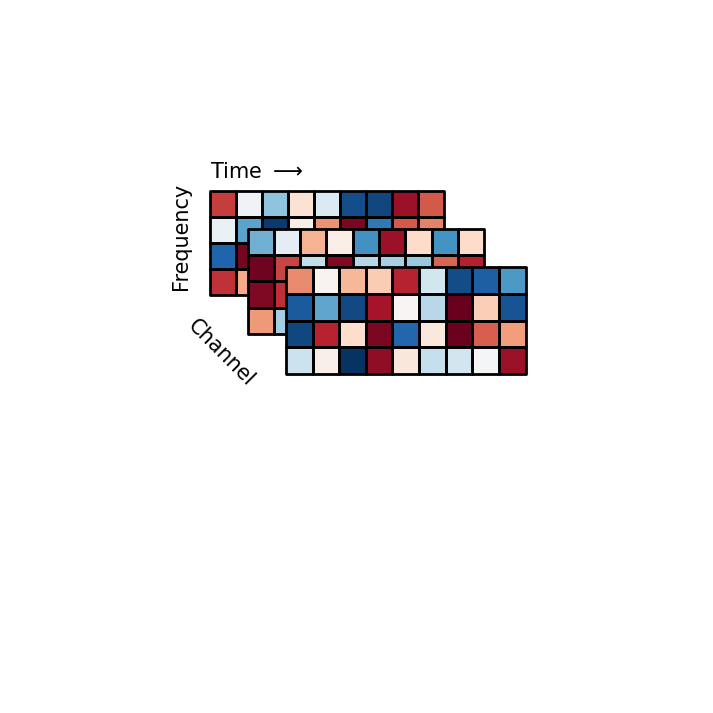

In [171]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(12)
# Create a 3D plot to represent a batch of samples
box_aspect = (1, 1, 1) 
figsize=(9, 9)
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# Parameters
num_channels = 3
seq_len = 10
freq_size = 5

# Generate coordinates for the 3D plot
x = np.arange(0, freq_size)
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)
# feature_map = np.flip(feature_map, axis=1)

colors = plt.cm.RdBu(feature_map)
# colors = plt.cm.bwr_r(feature_map)

# max_val = np.max(feature_map)
# pixel_tol = max_val - (max_val * 0.5)

# colors[feature_map < pixel_tol] = 1

shift_scale = 1.5 # make sure is not even or pannels will appear to overlap
# Plot each sample in the batch
for i in range(num_channels):
    # plot with actual colors  
    x_coord = X + (shift_scale*i)
    y_coord = Y + (shift_scale*i)
    z_coord = Z + (shift_scale*i)
    ax.plot_surface(x_coord, y_coord, z_coord, alpha=1, rstride=1, cstride=1, linewidth=0, edgecolor='k', facecolors=colors[:,:,i], antialiased=True, shade=False)
    # Plot the surface again to add edgecolors
    ax.plot_surface(x_coord, y_coord, z_coord, rstride=1, cstride=1, alpha=0.0, linewidth=2, edgecolors='k', antialiased=True, shade=False)

# Customize ticks
# ax.set_xticks(np.arange(0, seq_len, step=1))
# ax.set_yticks(np.arange(0, freq_size, step=1))
# ax.set_zticks(np.arange(0, num_channels, step=1))
ax.view_init(elev=90, azim=0)

# Set aspect ratio
scaling = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
ax.auto_scale_xyz(*[[np.min(scaling), np.max(scaling)]]*3)

plt.axis('off')
# Add axis labels as text 
ax.text(-0.5, 0, 0, "Time $\longrightarrow$", color='black', fontsize=15,)
ax.text(7.5, -1, 0, "Channel", (45,45,0), color='black', fontsize=15)
ax.text(3.66, -1.5, 0, "Frequency",  (90,0,0), color='black', fontsize=15)

# ax.set_xlabel('Frequency')

# Title
# plt.title('Batch of 5 Samples.\n(Samples x Seq Len x Embedding size)')

ax.set_box_aspect(box_aspect)


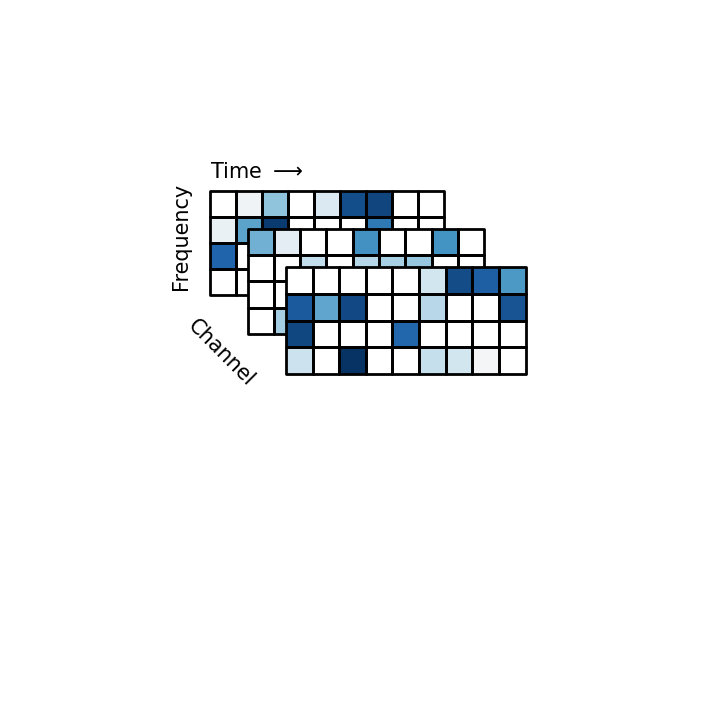

In [141]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(12)
# Create a 3D plot to represent a batch of samples
box_aspect = (1, 1, 1) 
figsize=(9, 9)
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# Parameters
num_channels = 3
seq_len = 10
freq_size = 5

# Generate coordinates for the 3D plot
x = np.arange(0, freq_size)
y = np.arange(0, seq_len)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

feature_map = np.random.rand(seq_len, freq_size, num_channels)
# feature_map = np.flip(feature_map, axis=1)

colors = plt.cm.RdBu(feature_map)
# colors = plt.cm.bwr_r(feature_map)

max_val = np.max(feature_map)
pixel_tol = max_val - (max_val * 0.5)

colors[feature_map < pixel_tol] = 1

shift_scale = 1.5 # make sure is not even or pannels will appear to overlap
# Plot each sample in the batch
for i in range(num_channels):
    # plot with actual colors  
    x_coord = X + (shift_scale*i)
    y_coord = Y + (shift_scale*i)
    z_coord = Z + (shift_scale*i)
    ax.plot_surface(x_coord, y_coord, z_coord, alpha=1, rstride=1, cstride=1, linewidth=0, edgecolor='k', facecolors=colors[:,:,i], antialiased=True, shade=False)
    # Plot the surface again to add edgecolors
    ax.plot_surface(x_coord, y_coord, z_coord, rstride=1, cstride=1, alpha=0.0, linewidth=2, edgecolors='k', antialiased=True, shade=False)

# Customize ticks
# ax.set_xticks(np.arange(0, seq_len, step=1))
# ax.set_yticks(np.arange(0, freq_size, step=1))
# ax.set_zticks(np.arange(0, num_channels, step=1))
ax.view_init(elev=90, azim=0)

# Set aspect ratio
scaling = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
ax.auto_scale_xyz(*[[np.min(scaling), np.max(scaling)]]*3)

plt.axis('off')
# Add axis labels as text 
ax.text(-0.5, 0, 0, "Time $\longrightarrow$", color='black', fontsize=15,)
ax.text(7.5, -1, 0, "Channel", (45,45,0), color='black', fontsize=15)
ax.text(3.66, -1.5, 0, "Frequency",  (90,0,0), color='black', fontsize=15)

# ax.set_xlabel('Frequency')

# Title
# plt.title('Batch of 5 Samples.\n(Samples x Seq Len x Embedding size)')

ax.set_box_aspect(box_aspect)
